# DBSCAN — Density-Based Spatial Clustering

**Dataset:** Global Tree Cover Loss by Country (threshold = 30%)

---

## What is DBSCAN?

DBSCAN stands for **Density-Based Spatial Clustering of Applications with Noise**.

### The Core Idea
K-Means asks *"how many clusters are there?"* — you have to tell it. DBSCAN doesn't need to know. Instead, it asks: **"which points are close together?"**

DBSCAN groups points that are **densely packed**, and marks isolated points as **noise/outliers**. This makes it great for real-world data where:
- Clusters have irregular shapes (not neat circles)
- There are genuine outlier countries that don't fit any group

---

## Two Key Parameters

DBSCAN only needs two things from you:

| Parameter | Symbol | Meaning |
|---|---|---|
| **Epsilon** | `ε` (eps) | The radius of the neighborhood around a point — how close is "close"? |
| **Min Samples** | `min_samples` | How many neighbors a point needs to be considered a **core point** |

Both are **user-defined** — you choose them.

---

## Three Types of Points

Once you fix ε and min_samples, DBSCAN labels every point as one of:

1. **Core point** — Has at least `min_samples` neighbors within distance ε. This point *anchors* a cluster.
2. **Border point** — Is within ε of a core point, but doesn't have enough neighbors to be a core itself. It *belongs* to the cluster but doesn't extend it.
3. **Noise point** — Not within ε of any core point. It gets labeled **-1** (no cluster).

---

## The Algorithm (Step by Step)

1. Pick any unvisited point
2. Count how many points are within distance ε
3. If count ≥ min_samples → it's a **core point** → start a new cluster
4. Expand the cluster by recursively adding all density-reachable points
5. If count < min_samples → mark as **noise** for now (it might become a border point later)
6. Repeat until all points are visited

The key insight: a cluster can *grow* through core points, but stops at border points.

---

## Step 1 — Import Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

print("Libraries imported successfully!")

Libraries imported successfully!


---

## Step 2 — Load and Prepare the Data

In [6]:
# Load the dataset
df = pd.read_csv('data/Tree_Cover_Loss_Country.csv')

# Use threshold = 30 (standard definition of tree cover)
df = df[df['threshold'] == 30].copy()

print(f"Dataset shape: {df.shape}")
print(f"Number of countries: {df['country'].nunique()}")
df.head()

Dataset shape: (236, 28)
Number of countries: 236


,country,threshold,area_ha,extent_2000_ha,extent_2010_ha,gain_2000-2020_ha,tc_loss_ha_2001,tc_loss_ha_2002,tc_loss_ha_2003,tc_loss_ha_2004,...,tc_loss_ha_2013,tc_loss_ha_2014,tc_loss_ha_2015,tc_loss_ha_2016,tc_loss_ha_2017,tc_loss_ha_2018,tc_loss_ha_2019,tc_loss_ha_2020,tc_loss_ha_2021,tc_loss_ha_2022
5,Afghanistan,30,64385715,205791,71797,10741,88,179,244,201,...,1,3,0,0,0,26,17,37,26,6
13,Akrotiri and Dhekelia,30,23448,456,383,42,2,1,0,2,...,1,1,5,9,1,1,1,1,1,0
21,Albania,30,2873537,648680,589017,16472,3729,890,614,3237,...,2570,1052,284,928,1689,2049,1074,1118,1686,2095
29,Algeria,30,230804377,1223621,821606,89152,3469,3010,3831,4374,...,6927,9523,5707,8011,45979,5764,6291,13073,20473,13443
37,Andorra,30,45196,19004,18962,120,2,1,0,23,...,3,1,2,1,3,15,8,27,2,15


In [7]:
# Select the yearly loss columns as features
loss_cols = [c for c in df.columns if c.startswith('tc_loss_ha_')]
print(f"Using {len(loss_cols)} yearly loss columns as features: {loss_cols[0]} to {loss_cols[-1]}")

# Drop rows with all-zero loss (countries with no tree cover loss)
df_features = df[loss_cols].copy()
mask = df_features.sum(axis=1) > 0
df_filtered = df[mask].copy()
X_raw = df_filtered[loss_cols].values
countries = df_filtered['country'].values

print(f"Countries with non-zero loss: {len(countries)}")

Using 22 yearly loss columns as features: tc_loss_ha_2001 to tc_loss_ha_2022
Countries with non-zero loss: 211


In [8]:
# Standardize the features
# DBSCAN uses distance — so scale matters! Without scaling, countries with
# large absolute losses (Brazil, Russia) would dominate the distance calculations.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print("Features scaled. Mean ≈ 0, Std ≈ 1 for each year.")
print(f"Feature matrix shape: {X_scaled.shape}")

Features scaled. Mean ≈ 0, Std ≈ 1 for each year.
Feature matrix shape: (211, 22)


---

## Step 3 — Choose eps Using the k-Distance Graph

### How do you pick ε?

The most common method: **the k-distance graph** (also called the "elbow method for DBSCAN").

1. For each point, compute the distance to its `k`-th nearest neighbor (where `k = min_samples`)
2. Sort these distances and plot them
3. The "elbow" in the curve is a good estimate for ε

**Why?** Points in dense clusters will have a small k-distance. Points at the edge of clusters or in noise have a larger k-distance. The elbow separates them.

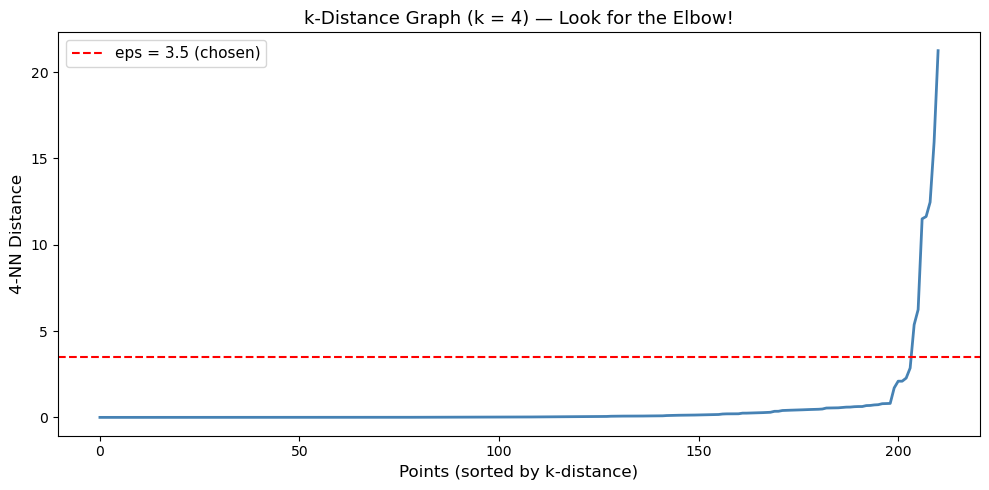


The elbow around 3.5 suggests eps ≈ 3.5


In [9]:
from sklearn.neighbors import NearestNeighbors

# We'll try min_samples = 4 (a common starting point)
min_samples = 4

# Fit nearest neighbors
nbrs = NearestNeighbors(n_neighbors=min_samples).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)

# The k-distance is the distance to the (min_samples)th nearest neighbor
k_distances = distances[:, -1]  # last column = farthest of the k neighbors
k_distances_sorted = np.sort(k_distances)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_distances_sorted, color='steelblue', linewidth=2)
ax.axhline(y=3.5, color='red', linestyle='--', label='eps = 3.5 (chosen)')
ax.set_xlabel('Points (sorted by k-distance)', fontsize=12)
ax.set_ylabel(f'{min_samples}-NN Distance', fontsize=12)
ax.set_title(f'k-Distance Graph (k = {min_samples}) — Look for the Elbow!', fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('dbscan_kdistance.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nThe elbow around 3.5 suggests eps ≈ 3.5")

---

## Step 4 — Fit DBSCAN

In [10]:
# Fit DBSCAN with chosen parameters
eps = 3.5
min_samples = 4

dbscan = DBSCAN(eps=eps, min_samples=min_samples)
labels = dbscan.fit_predict(X_scaled)

# Analyze results
unique_labels = set(labels)
n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
n_noise = np.sum(labels == -1)

print(f"eps = {eps}, min_samples = {min_samples}")
print(f"\nClusters found: {n_clusters}")
print(f"Noise points:   {n_noise} ({n_noise/len(labels)*100:.1f}% of countries)")
print(f"\nCluster sizes:")
for label in sorted(unique_labels):
    count = np.sum(labels == label)
    name = 'NOISE' if label == -1 else f'Cluster {label}'
    print(f"  {name}: {count} countries")

eps = 3.5, min_samples = 4

Clusters found: 1
Noise points:   7 (3.3% of countries)

Cluster sizes:
  NOISE: 7 countries
  Cluster 0: 204 countries


---

## Step 5 — Explore the Clusters

In [11]:
# Add cluster labels back to the dataframe
df_filtered = df_filtered.copy()
df_filtered['cluster'] = labels

# Compute total loss 2001–2022 for context
df_filtered['total_loss_ha'] = df_filtered[loss_cols].sum(axis=1)

# Show each cluster
for label in sorted(set(labels)):
    subset = df_filtered[df_filtered['cluster'] == label]
    name = 'NOISE / Outliers' if label == -1 else f'Cluster {label}'
    print(f"\n{'='*55}")
    print(f"  {name} — {len(subset)} countries")
    print(f"{'='*55}")
    top = subset.nlargest(10, 'total_loss_ha')[['country','total_loss_ha']]
    for _, row in top.iterrows():
        print(f"  {row['country']:<35} {row['total_loss_ha']:>15,.0f} ha")


  NOISE / Outliers — 7 countries
  Russia                                   80,296,223 ha
  Brazil                                   66,126,530 ha
  Canada                                   48,911,423 ha
  United States                            46,484,058 ha
  Indonesia                                29,447,626 ha
  Democratic Republic of the Congo         18,365,345 ha
  Australia                                 8,846,939 ha

  Cluster 0 — 204 countries
  China                                    11,487,131 ha
  Malaysia                                  8,917,578 ha
  Bolivia                                   7,268,727 ha
  Paraguay                                  6,770,792 ha
  Argentina                                 6,549,750 ha
  Sweden                                    5,497,596 ha
  Colombia                                  5,194,179 ha
  Mexico                                    4,660,372 ha
  Madagascar                                4,618,727 ha
  Myanmar                

---

## Step 6 — Visualize with PCA

Our data has 22 dimensions (one per year). We'll use **PCA** to compress it down to 2D so we can plot it.

PCA is another unsupervised algorithm — it finds the directions of maximum variance. We use it here just for visualization.

Variance explained by 2 components: 97.0%


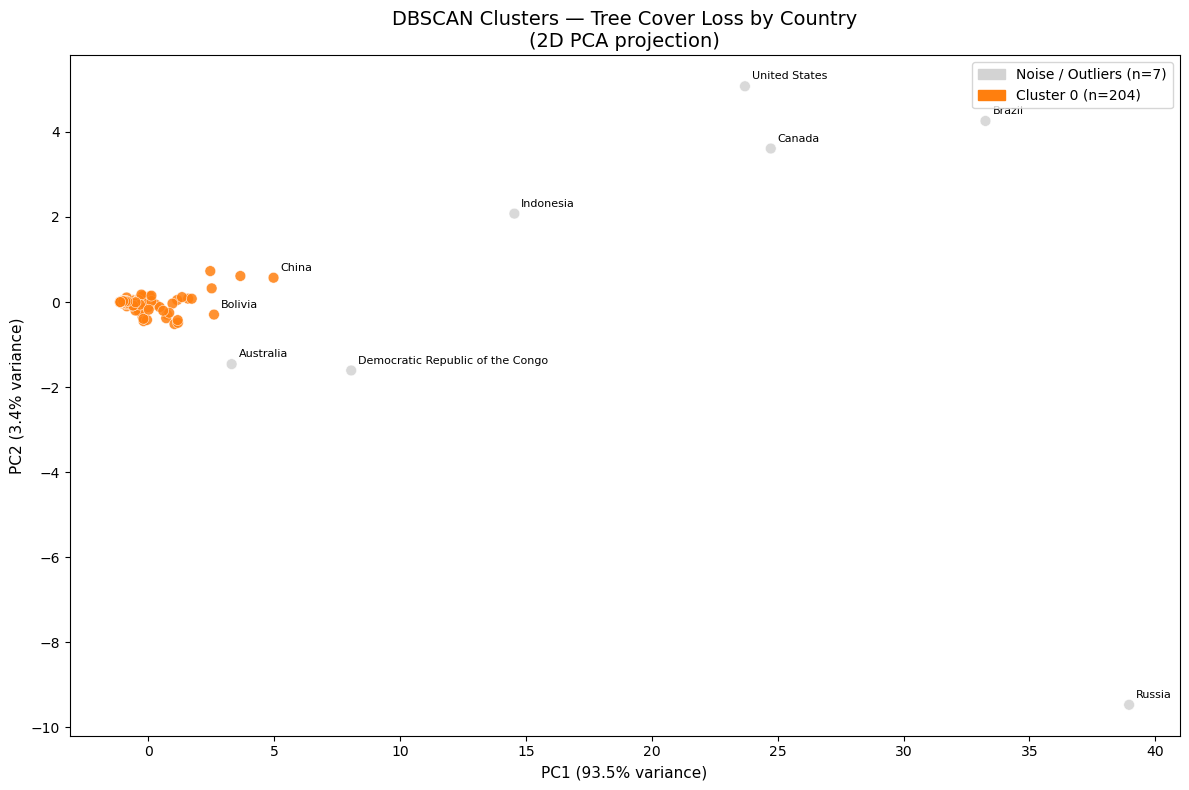

In [12]:
# Reduce to 2D with PCA
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)

print(f"Variance explained by 2 components: {pca.explained_variance_ratio_.sum()*100:.1f}%")

# Assign colors
cluster_ids = sorted(set(labels))
palette = plt.cm.tab10.colors
color_map = {}
for i, cid in enumerate(cluster_ids):
    if cid == -1:
        color_map[cid] = 'lightgray'
    else:
        color_map[cid] = palette[i % len(palette)]

point_colors = [color_map[l] for l in labels]

fig, ax = plt.subplots(figsize=(12, 8))

# Plot all points
ax.scatter(X_2d[:, 0], X_2d[:, 1],
           c=point_colors, s=60, alpha=0.85,
           edgecolors='white', linewidths=0.4)

# Label interesting countries
notable = ['Brazil', 'Russia', 'Canada', 'Indonesia', 'United States', 'China',
           'Democratic Republic of the Congo', 'Bolivia', 'Australia']
for i, country in enumerate(countries):
    if country in notable:
        ax.annotate(country, (X_2d[i, 0], X_2d[i, 1]),
                    fontsize=8, xytext=(5, 5), textcoords='offset points')

# Legend
legend_handles = []
for cid in cluster_ids:
    name = 'Noise / Outliers' if cid == -1 else f'Cluster {cid}'
    count = np.sum(labels == cid)
    patch = mpatches.Patch(color=color_map[cid], label=f'{name} (n={count})')
    legend_handles.append(patch)

ax.legend(handles=legend_handles, fontsize=10, loc='upper right')
ax.set_title('DBSCAN Clusters — Tree Cover Loss by Country\n(2D PCA projection)', fontsize=14)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=11)
plt.tight_layout()
plt.savefig('dbscan_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

---

## Step 7 — Average Loss Profile per Cluster

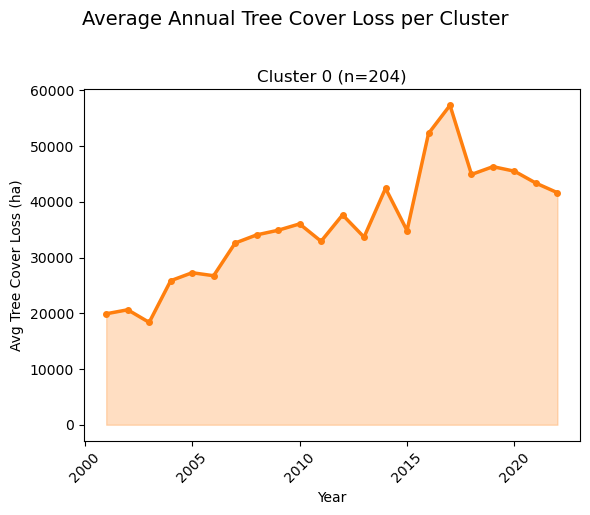

In [13]:
years = [int(c.split('_')[-1]) for c in loss_cols]

# Only plot real clusters (not noise) unless noise is interesting
real_clusters = [cid for cid in cluster_ids if cid != -1]

fig, axes = plt.subplots(1, len(real_clusters), figsize=(6 * len(real_clusters), 5),
                          sharey=False)
if len(real_clusters) == 1:
    axes = [axes]

for ax, cid in zip(axes, real_clusters):
    subset = df_filtered[df_filtered['cluster'] == cid]
    mean_loss = subset[loss_cols].mean()
    
    ax.fill_between(years, mean_loss, alpha=0.25, color=color_map[cid])
    ax.plot(years, mean_loss, color=color_map[cid], linewidth=2.5, marker='o', markersize=4)
    ax.set_title(f'Cluster {cid} (n={len(subset)})', fontsize=12)
    ax.set_xlabel('Year', fontsize=10)
    ax.set_ylabel('Avg Tree Cover Loss (ha)', fontsize=10)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Average Annual Tree Cover Loss per Cluster', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('dbscan_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

---

## Step 8 — Who Are the Outliers (Noise)?

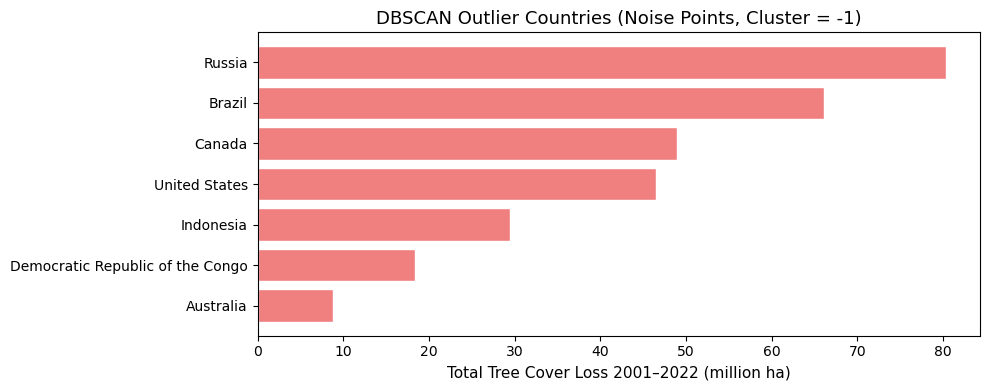


Outliers — countries so unique DBSCAN couldn't group them:
                         country  total_loss_ha
                          Russia       80296223
                          Brazil       66126530
                          Canada       48911423
                   United States       46484058
                       Indonesia       29447626
Democratic Republic of the Congo       18365345
                       Australia        8846939


In [14]:
noise = df_filtered[df_filtered['cluster'] == -1][['country', 'total_loss_ha']]
noise_sorted = noise.sort_values('total_loss_ha', ascending=False)

fig, ax = plt.subplots(figsize=(10, max(4, len(noise_sorted) * 0.35)))
bars = ax.barh(noise_sorted['country'], noise_sorted['total_loss_ha'] / 1e6,
               color='lightcoral', edgecolor='white')
ax.set_xlabel('Total Tree Cover Loss 2001–2022 (million ha)', fontsize=11)
ax.set_title('DBSCAN Outlier Countries (Noise Points, Cluster = -1)', fontsize=13)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('dbscan_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nOutliers — countries so unique DBSCAN couldn't group them:")
print(noise_sorted.to_string(index=False))

---

## Step 9 — Silhouette Score (Evaluation)

We can evaluate DBSCAN using the **silhouette score** — the same metric we used for K-Means.

⚠️ **Important:** Silhouette score only works on points that are assigned to a cluster (not noise). We skip noise points.

- Score near **+1**: clusters are dense and well-separated
- Score near **0**: clusters overlap
- Score near **-1**: points are in the wrong cluster

In [15]:
# Filter out noise for silhouette calculation
mask_cluster = labels != -1

if mask_cluster.sum() > 1 and len(set(labels[mask_cluster])) > 1:
    score = silhouette_score(X_scaled[mask_cluster], labels[mask_cluster])
    print(f"Silhouette Score (non-noise points only): {score:.4f}")
    
    if score > 0.5:
        print("Strong cluster structure!")
    elif score > 0.25:
        print("Reasonable cluster structure.")
    else:
        print("Weak cluster structure — may want to tune eps and min_samples.")
else:
    print("Not enough clustered points to compute silhouette score.")

print(f"\nNote: {n_noise} noise points ({n_noise/len(labels)*100:.1f}%) were excluded from this score.")

Not enough clustered points to compute silhouette score.

Note: 7 noise points (3.3%) were excluded from this score.


---

## Step 10 — Sensitivity to Parameters

DBSCAN's results depend heavily on `eps` and `min_samples`. Let's see how the number of clusters and noise changes as we vary `eps`.

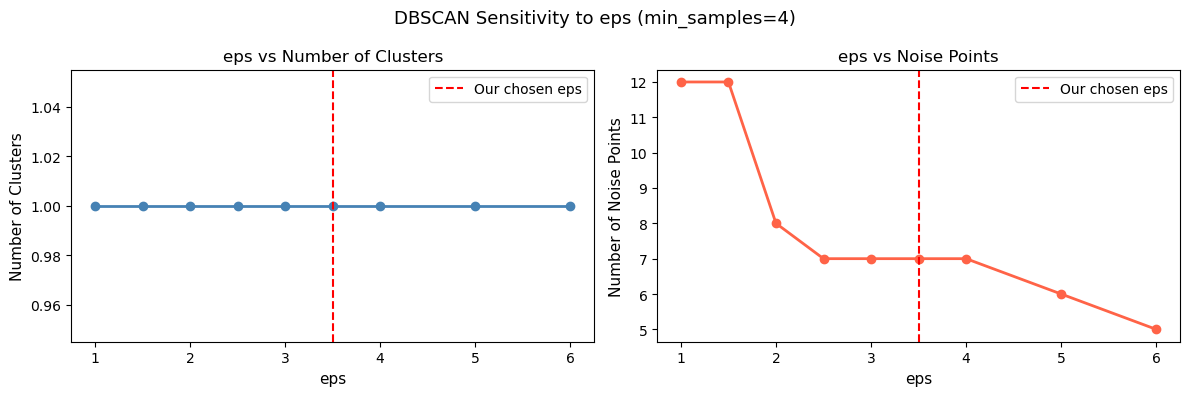

 eps  n_clusters  n_noise
 1.0           1       12
 1.5           1       12
 2.0           1        8
 2.5           1        7
 3.0           1        7
 3.5           1        7
 4.0           1        7
 5.0           1        6
 6.0           1        5


In [16]:
eps_values = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 5.0, 6.0]
results = []

for e in eps_values:
    lbl = DBSCAN(eps=e, min_samples=4).fit_predict(X_scaled)
    n_cl = len(set(lbl)) - (1 if -1 in lbl else 0)
    n_ns = np.sum(lbl == -1)
    results.append({'eps': e, 'n_clusters': n_cl, 'n_noise': n_ns})

res_df = pd.DataFrame(results)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(res_df['eps'], res_df['n_clusters'], marker='o', color='steelblue', linewidth=2)
ax1.axvline(x=3.5, color='red', linestyle='--', label='Our chosen eps')
ax1.set_xlabel('eps', fontsize=11)
ax1.set_ylabel('Number of Clusters', fontsize=11)
ax1.set_title('eps vs Number of Clusters', fontsize=12)
ax1.legend()

ax2.plot(res_df['eps'], res_df['n_noise'], marker='o', color='tomato', linewidth=2)
ax2.axvline(x=3.5, color='red', linestyle='--', label='Our chosen eps')
ax2.set_xlabel('eps', fontsize=11)
ax2.set_ylabel('Number of Noise Points', fontsize=11)
ax2.set_title('eps vs Noise Points', fontsize=12)
ax2.legend()

plt.suptitle('DBSCAN Sensitivity to eps (min_samples=4)', fontsize=13)
plt.tight_layout()
plt.savefig('dbscan_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

print(res_df.to_string(index=False))

---

## Step 11 — Conclusion

### What did we find?

We applied DBSCAN to cluster countries by their annual tree cover loss patterns.

### DBSCAN vs K-Means: Key Differences

| Feature | K-Means | DBSCAN |
|---|---|---|
| **Needs k?** | Yes — you pick k upfront | No — discovers it automatically |
| **Cluster shape** | Assumes spherical clusters | Any shape |
| **Outliers** | Every point goes in a cluster | Outliers get label -1 |
| **Parameters** | k | eps, min_samples |
| **Works best when** | You know approx. how many groups exist | Data has density-based structure and outliers |

### Why DBSCAN Matters Here

K-Means forced every country into a cluster. DBSCAN identified a few genuine outliers — countries with deforestation patterns so extreme (Brazil) or unusual (specific to geography and policy) that they genuinely don't belong to any group.

### Limitations

1. **Sensitive to eps and min_samples** — the results change significantly with different values
2. **Struggles with varying density** — if some clusters are very dense and others sparse, one eps can't capture both
3. **High dimensions** — distance becomes less meaningful in 22 dimensions (we relied on standardization to help)

### What's Next?

We've now covered three unsupervised clustering algorithms: **PCA**, **K-Means**, and **DBSCAN**. Each sees the data differently — and together they give a much richer picture than any one alone!